<a href="https://colab.research.google.com/github/Nikki-py/bad_road_condition_detection/blob/main/bad_road_condition_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.svm import SVC
from sklearn.ensemble import IsolationForest

parantha - 1
siemens - 2
wipro avenue - 3
wipro village - 4
bsnl - 5

In [ ]:
acc = pd.read_csv('accelerometerTrainingData (1).csv')

In [ ]:
acc = acc.dropna()
acc = acc.drop_duplicates()

In [ ]:
std = acc['magmean'].std()
mean = acc['magmean'].mean()

print(mean)
print(std)

1.897538808804328e-12
1.6254766459626255


In [ ]:
x = acc[["magmean"]].values

In [ ]:
scl = StandardScaler()
x_scaled = scl.fit_transform(x)

m = x_scaled.mean()
s = x_scaled.std()

print(m)
print(s)

-1.3353142202468676e-17
1.0


In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
acc["cluster"] = kmeans.fit_predict(x_scaled)

In [ ]:
cluster_means = acc.groupby('cluster')['magmean'].apply(lambda x: abs(x).mean())

In [ ]:
cm = cluster_means.sort_values()

In [ ]:
print (cm)

cluster
0    0.515160
1    1.962463
2    3.301387
Name: magmean, dtype: float64


In [ ]:
cluster_mapping = {0:"smooth road", 1:"bad road", 2:"pothole"}

In [ ]:
acc['labels'] = acc['cluster'].map(cluster_mapping)

In [ ]:
print(acc.head(10))

   Unnamed: 0        x        y        z   magmean  cluster       labels
0           0  6.82274  0.45033  3.82030 -1.738313        1     bad road
1           1  5.85648  0.40392  4.50587 -2.170467        1     bad road
2           2  6.10358  0.06442  4.13556 -2.197792        1     bad road
3           3  6.51970  0.16652  5.52556 -1.022895        1     bad road
4           4  6.99959  0.24277  5.96222 -0.372868        0  smooth road
5           5  7.93651  0.70926  6.19339  0.521280        0  smooth road
6           6  8.41479  0.58516  7.28528  1.574928        0  smooth road
7           7  7.73375  0.48204  8.23373  1.735765        2      pothole
8           8  8.33945  0.40234  7.18883  1.446841        0  smooth road
9           9  7.37863  0.71304  7.23845  0.790114        0  smooth road


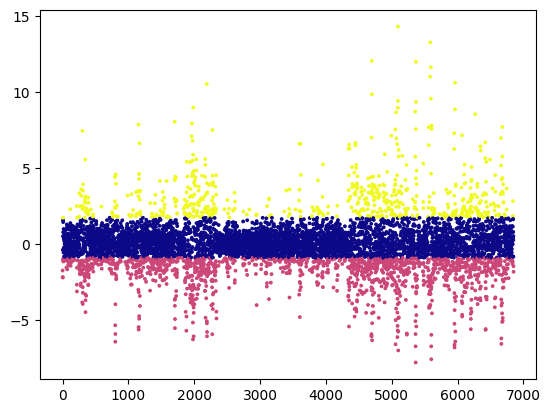

In [ ]:
plt.scatter(range(len(acc)),acc["magmean"],c=acc["cluster"],s=3, cmap="plasma")
plt.show()

In [ ]:
acc["mean_xyz"] = acc[["x", "y", "z"]].mean(axis=1)
acc["std_xyz"] = acc[["x", "y", "z"]].std(axis=1)
acc["max_xyz"] = acc[["x", "y", "z"]].max(axis=1)
acc["min_xyz"] = acc[["x", "y", "z"]].min(axis=1)

acc["mean_diff"] = acc["mean_xyz"].diff()

acc = acc.dropna()

In [ ]:
upper = acc["magmean"].max() / 2
lower = acc["magmean"].min() / 2

acc["label"] = ((acc["magmean"] > upper) | (acc["magmean"] < lower)).astype(int)

X = acc[["x", "y", "z", "mean_xyz", "max_xyz", "min_xyz", "mean_diff"]]
y = acc["label"]

In [ ]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = SVC(kernel='rbf')
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

train_pred = model.predict(X_train_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9948905109489051


threshold values for gyroscope

good road : -0.15 to 0.15

bad road : -0.30 to 0.30

pothole : beyond -0.30 and 0.30

In [ ]:
import pandas as pd

road_data = {}

for i in range(1, 6):

    gyro = pd.read_csv(f"{i}_gyroscope.csv")
    gps = pd.read_csv(f"{i}_gps.csv")

    gyro["mean_xyz"] = gyro[["x", "y", "z"]].mean(axis=1)
    gyro["mean_xyz_diff"] = gyro["mean_xyz"].diff().abs()

    def classify(val):
        if -0.15 <= val <= 0.15:
            return "smooth"
        elif -0.30 <= val <= 0.30:
            return "bad_road"
        else:
            return "pothole"

    gyro["road_condition"] = gyro["mean_xyz"].apply(classify)

    gps['time'] = pd.to_datetime(gps['time'])
    gyro['time'] = pd.to_datetime(gyro['time'])

    gps = gps.sort_values('time')
    gyro = gyro.sort_values('time')

    merged = pd.merge_asof(
        gps,
        gyro[['time', 'road_condition']],
        on='time',
        direction='nearest'
    )

    merged = merged.drop(columns=['altitude', 'speed', 'satellites in view', 'satellites in use'])

    road_data[f"road_{i}"] = merged

    print (road_data[f"road_{i}"].head(10))
    print(df.shape())

                           time        lat        lng  accuracy road_condition
0 1970-01-01 00:00:00.000000717  12.850063  77.662575        93       bad_road
1 1970-01-01 00:00:00.000001714  12.850063  77.662575        93       bad_road
2 1970-01-01 00:00:00.000002713  12.850063  77.662575        93       bad_road
3 1970-01-01 00:00:00.000003712  12.850063  77.662575        93         smooth
4 1970-01-01 00:00:00.000004713  12.850063  77.662575        93         smooth
5 1970-01-01 00:00:00.000005764  12.850913  77.662024       800         smooth
6 1970-01-01 00:00:00.000006812  12.850913  77.662024       800         smooth
7 1970-01-01 00:00:00.000007815  12.850913  77.662024       800       bad_road
8 1970-01-01 00:00:00.000008862  12.850913  77.662024       800         smooth
9 1970-01-01 00:00:00.000009863  12.850913  77.662024       800         smooth


NameError: name 'df' is not defined

In [ ]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1339    2]
 [   5   24]]


In [ ]:
X = acc[['x', 'y', 'z']]

iso_model = IsolationForest(contamination=0.05, random_state=42)
iso_model.fit(X)

acc['anomaly'] = iso_model.predict(X)

acc['anomaly'] = acc['anomaly'].map({1: 0, -1: 1})

print(acc['anomaly'].value_counts())

def detect_anomaly(x, y, z):
    data = [[x, y, z]]
    pred = iso_model.predict(data)
    return 1 if pred[0] == -1 else 0

print(detect_anomaly(0.5, -0.3, 11.2))

anomaly
0    6507
1     343
Name: count, dtype: int64
1


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
